# Импорт необходимых библиотек

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import drive
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

Вход в гугл драйв, где лежит датасет скаченный из Kaggle

In [29]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/go_emotions_dataset.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Показ первых 5 строк датасета для демонстрации его содержимого.

In [30]:
emotions_df = pd.read_csv(file_path)
emotions_df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Поиск пустых значений в датасете

In [31]:
missing = emotions_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
  print(missing)
else:
  print("Пропущенных значений нет")

Пропущенных значений нет


# Анализ распределения эмоций

Подситываем количество примеров для каждой категории и выводим топ-10 наиболее частых эмоций


In [32]:
def analyze_emotions(df):
  emotion_cols = [col for col in df.columns if col not in ['id', 'text', 'example_very_unclear']]
  print("=" * 60)
  print(f"Всего категорий эмоций: {len(emotion_cols)}")
  print(f"Список эмоций: {emotion_cols}")

  emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)

  print(f"\nРаспределение эмоций (топ-10):")
  print(emotion_counts.head(10))

  return emotion_cols, emotion_counts

emotions_list, emotions_count = analyze_emotions(emotions_df)

Всего категорий эмоций: 28
Список эмоций: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Распределение эмоций (топ-10):
neutral        55298
approval       17620
admiration     17131
annoyance      13618
gratitude      11625
disapproval    11424
curiosity       9692
amusement       9245
realization     8785
optimism        8715
dtype: int64


# Визуализация распределения эмоций



In [33]:
def plot_emotion_distribution(emotion_counts, top_n=15):
    plt.figure(figsize=(14, 8))

    top_emotions = emotion_counts.head(top_n)

    bars = plt.barh(range(len(top_emotions)), top_emotions.values,
                   color=sns.color_palette("viridis", len(top_emotions)))
    plt.yticks(range(len(top_emotions)), top_emotions.index)
    plt.xlabel('Количество примеров')
    plt.title(f'Распределение эмоций (топ-{top_n})', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()

    for i, (bar, val) in enumerate(zip(bars, top_emotions.values)):
        plt.text(val + max(top_emotions.values)*0.01, i, f'{val:,}', va='center')

    plt.tight_layout()
    plt.show()


def plot_emotion_distribution_vertical(emotion_counts):
    plt.figure(figsize=(16, 6))

    colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
    bars = plt.bar(emotion_counts.index, emotion_counts.values, color=colors)

    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Количество примеров')
    plt.title('Распределение всех категорий эмоций', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

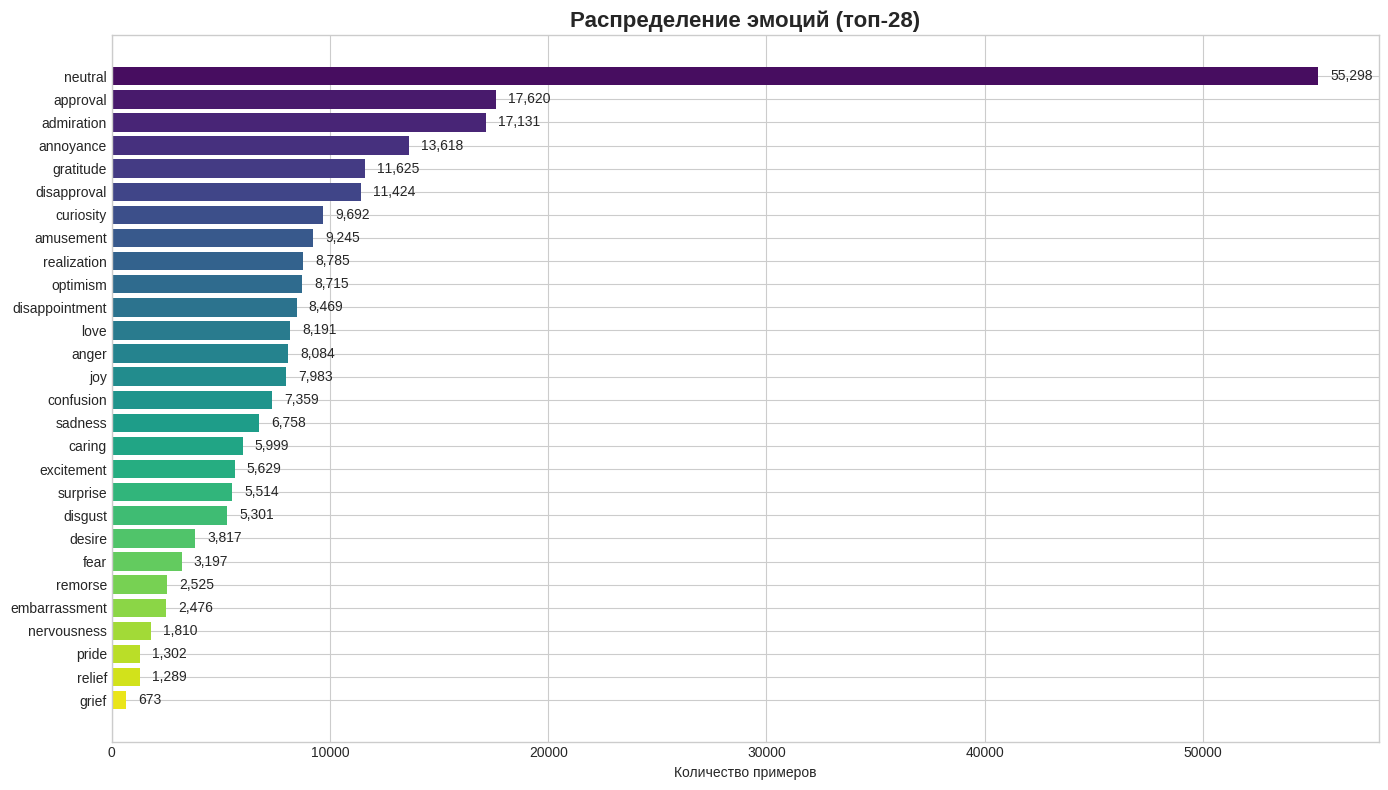

In [34]:
plot_emotion_distribution(emotions_count, top_n=28)

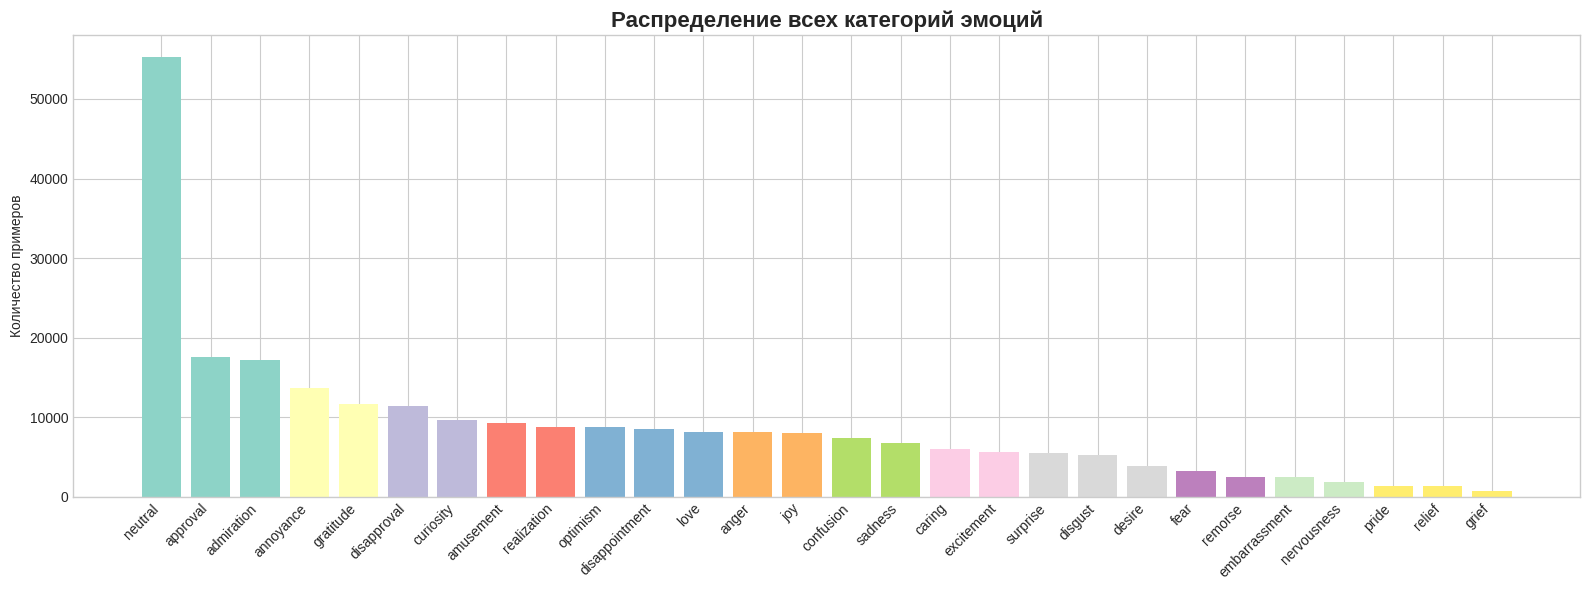

In [35]:
plot_emotion_distribution_vertical(emotions_count)

# Анализ текстовых данных

In [36]:
def analyze_text_data(df):

  df['text_length'] = df['text'].astype(str).apply(len)
  df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

  print(f"\nСтатистика длины текстов:")
  print(f"Средняя длина (символы): {df['text_length'].mean():.1f}")
  print(f"Медиана длины (символы): {df['text_length'].median():.1f}")
  print(f"Мин/Макс длина: {df['text_length'].min()} / {df['text_length'].max()}")

  print(f"\nСтатистика количества слов:")
  print(f"Среднее количество слов: {df['word_count'].mean():.1f}")
  print(f"Медиана количества слов: {df['word_count'].median():.1f}")
  print(f"Мин/Макс слов: {df['word_count'].min()} / {df['word_count'].max()}")

analyze_text_data(emotions_df)


Статистика длины текстов:
Средняя длина (символы): 69.3
Медиана длины (символы): 67.0
Мин/Макс длина: 2 / 703

Статистика количества слов:
Среднее количество слов: 13.0
Медиана количества слов: 13.0
Мин/Макс слов: 1 / 33


# Визуализация статистики текстов

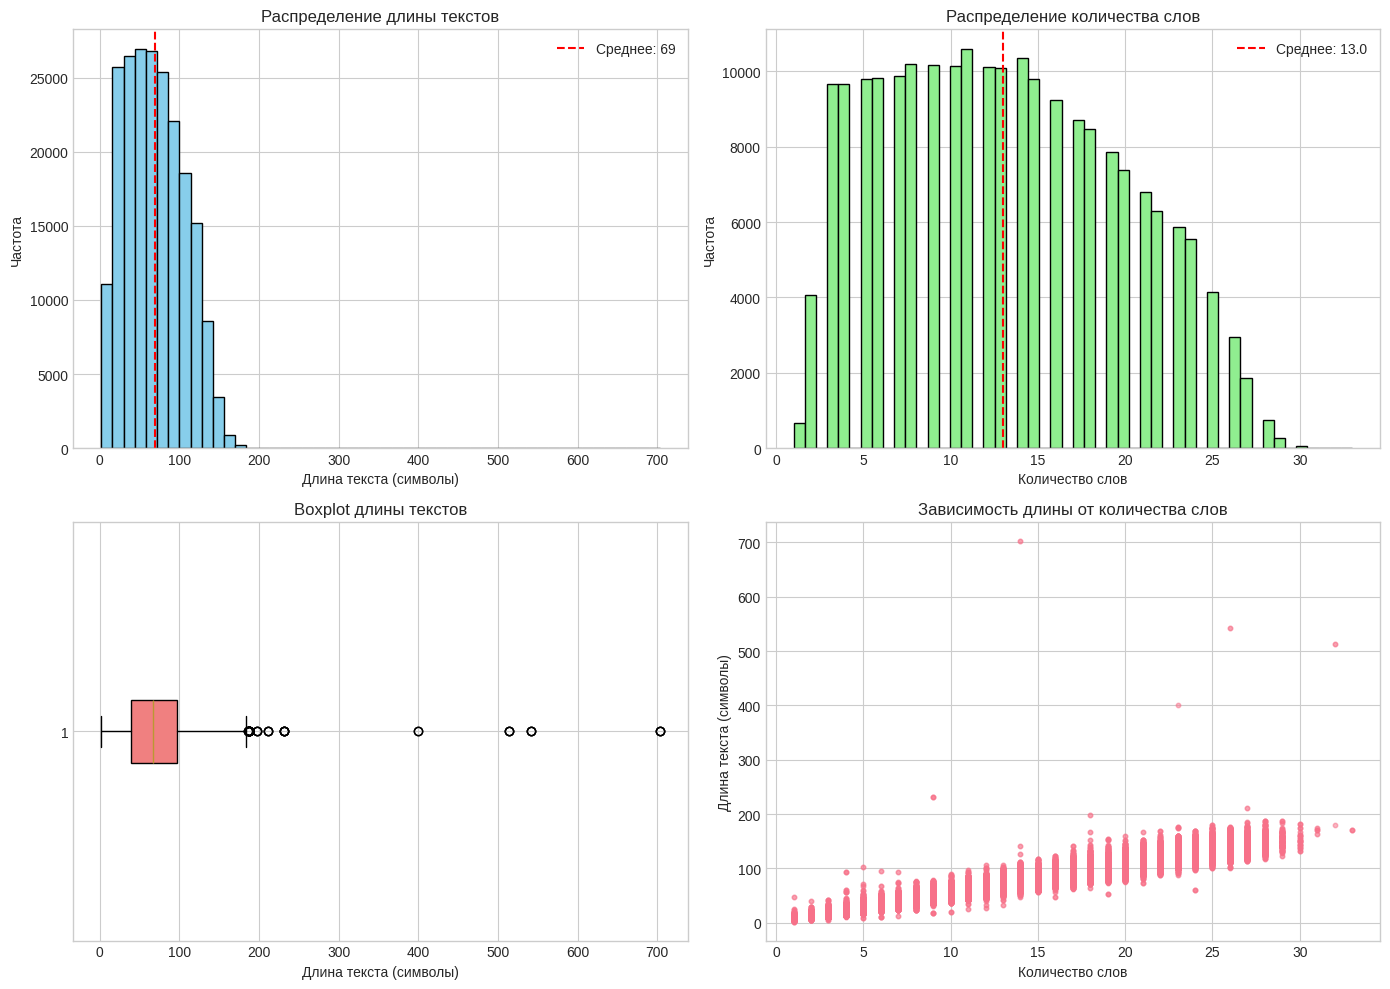

In [37]:
def plot_text_statistics(df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--',
                      label=f"Среднее: {df['text_length'].mean():.0f}")
    axes[0, 0].set_xlabel('Длина текста (символы)')
    axes[0, 0].set_ylabel('Частота')
    axes[0, 0].set_title('Распределение длины текстов')
    axes[0, 0].legend()

    axes[0, 1].hist(df['word_count'], bins=50, color='lightgreen', edgecolor='black')
    axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--',
                      label=f"Среднее: {df['word_count'].mean():.1f}")
    axes[0, 1].set_xlabel('Количество слов')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].set_title('Распределение количества слов')
    axes[0, 1].legend()

    axes[1, 0].boxplot(df['text_length'], vert=False, patch_artist=True,
                      boxprops=dict(facecolor='lightcoral'))
    axes[1, 0].set_xlabel('Длина текста (символы)')
    axes[1, 0].set_title('Boxplot длины текстов')

    axes[1, 1].scatter(df['word_count'], df['text_length'], alpha=0.3, s=10)
    axes[1, 1].set_xlabel('Количество слов')
    axes[1, 1].set_ylabel('Длина текста (символы)')
    axes[1, 1].set_title('Зависимость длины от количества слов')

    plt.tight_layout()
    plt.show()

plot_text_statistics(emotions_df)


МУЛЬТИЛАБЕЛЬНЫЙ АНАЛИЗ

Распределение количества эмоций на пример:
num_emotions
0       3411
1     171820
2      31187
3       4218
4        399
5        106
6         53
7         20
8          6
9          3
10         1
12         1
Name: count, dtype: int64

Статистика:
Примеров без эмоций (только нейтральные): 3411
Примеров с одной эмоцией: 171820
Примеров с 2+ эмоциями: 35994
Максимальное количество эмоций в одном примере: 12


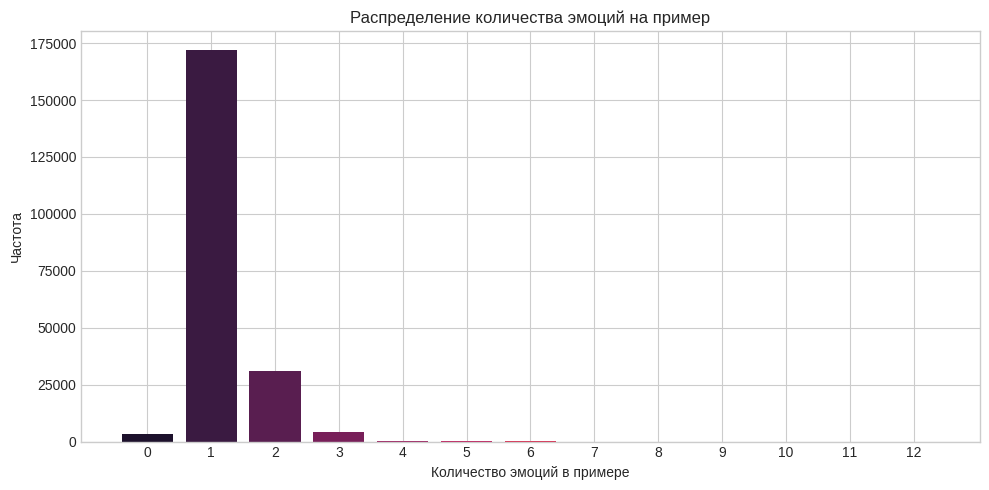

In [38]:
def analyze_multilabel(df, emotion_cols):
  print(f"\nМУЛЬТИЛАБЕЛЬНЫЙ АНАЛИЗ")
  print("=" * 60)

  df['num_emotions'] = df[emotion_cols].sum(axis=1)

  print(f"\nРаспределение количества эмоций на пример:")
  print(df['num_emotions'].value_counts().sort_index())

  print(f"\nСтатистика:")
  print(f"Примеров без эмоций (только нейтральные): {(df['num_emotions'] == 0).sum()}")
  print(f"Примеров с одной эмоцией: {(df['num_emotions'] == 1).sum()}")
  print(f"Примеров с 2+ эмоциями: {(df['num_emotions'] >= 2).sum()}")
  print(f"Максимальное количество эмоций в одном примере: {df['num_emotions'].max()}")


def plot_multilabel_distribution(df):
  plt.figure(figsize=(10, 5))

  counts = df['num_emotions'].value_counts().sort_index()
  plt.bar(counts.index, counts.values, color=sns.color_palette("rocket", len(counts)))

  plt.xlabel('Количество эмоций в примере')
  plt.ylabel('Частота')
  plt.title('Распределение количества эмоций на пример')
  plt.xticks(range(df['num_emotions'].max() + 1))
  plt.tight_layout()
  plt.show()

analyze_multilabel(emotions_df, emotions_list)
plot_multilabel_distribution(emotions_df)

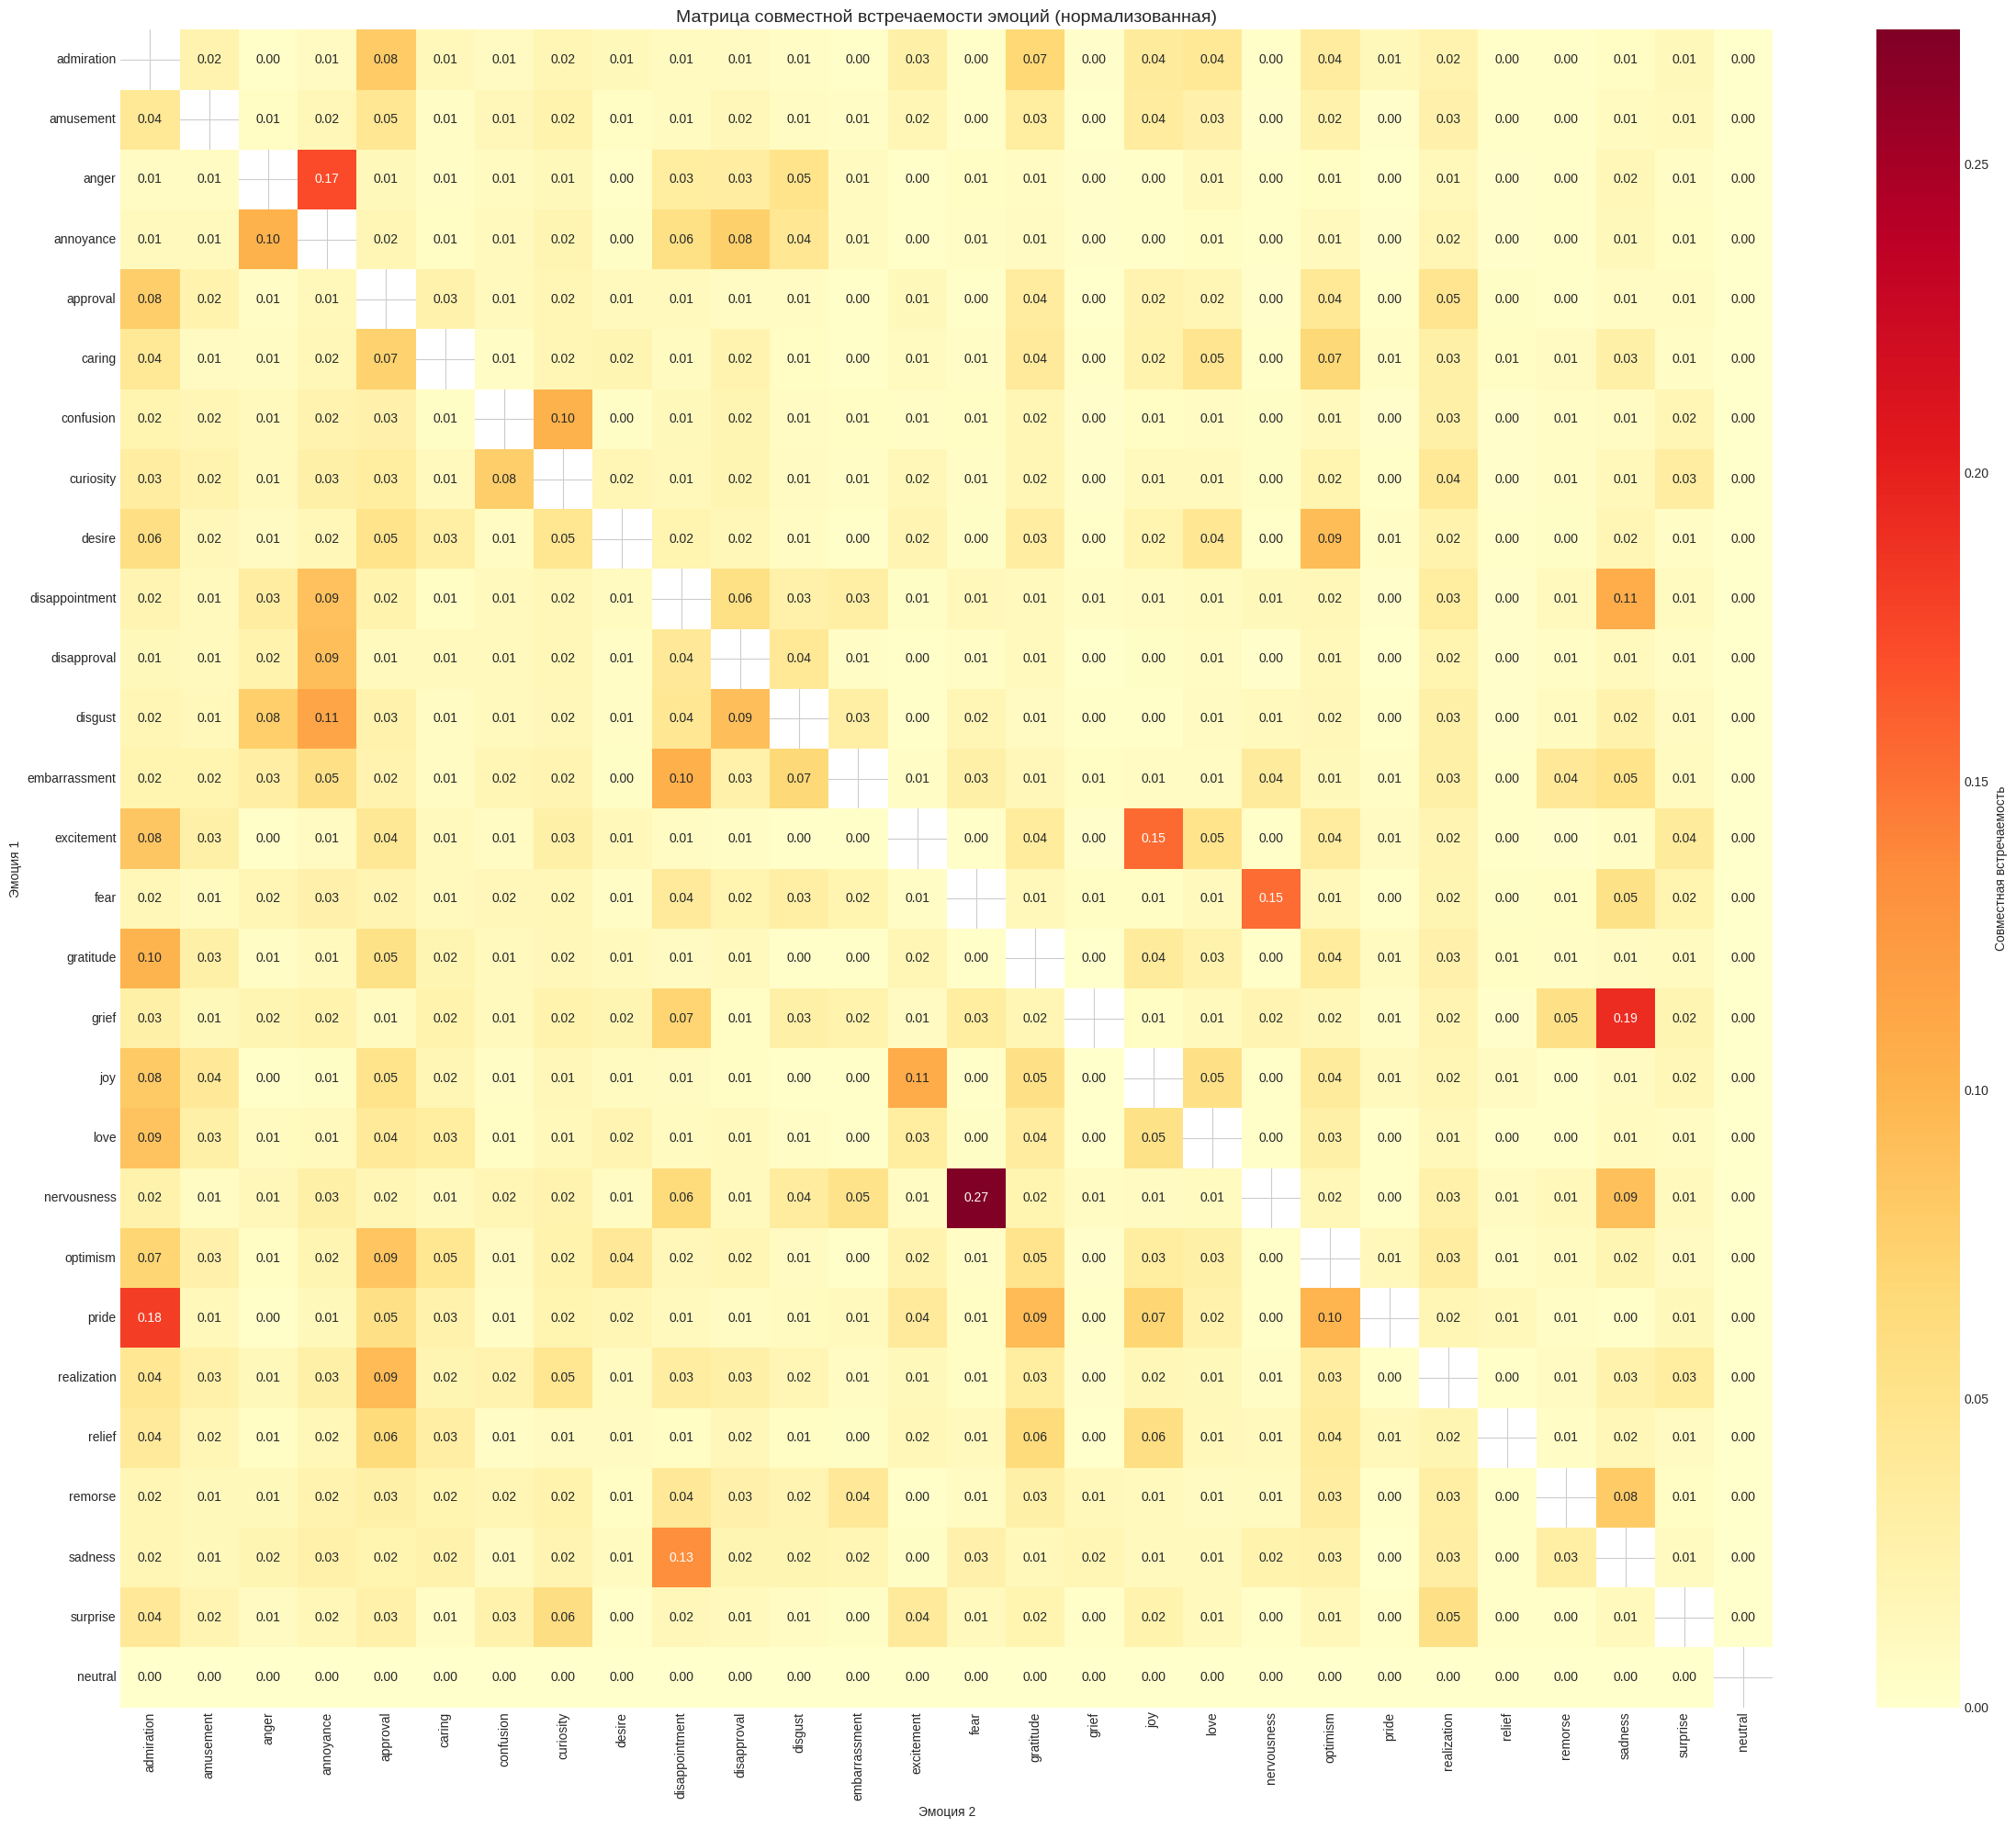

In [39]:
def plot_emotion_cooccurrence(df, emotion_cols):
    cooccurrence = df[emotion_cols].T @ df[emotion_cols]
    cooccurrence_norm = cooccurrence.astype(float).copy()

    for i in range(len(emotion_cols)):
        for j in range(len(emotion_cols)):
            if i != j:
                cooccurrence_norm.iloc[i, j] = cooccurrence.iloc[i, j] / df[emotion_cols[i]].sum()
            else:
                cooccurrence_norm.iloc[i, j] = np.nan

    plt.figure(figsize=(24, 20))
    sns.heatmap(cooccurrence_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=emotion_cols, yticklabels=emotion_cols, cbar_kws={'label': 'Совместная встречаемость'})
    plt.title('Матрица совместной встречаемости эмоций (нормализованная)', fontsize=14)
    plt.xlabel('Эмоция 2')
    plt.ylabel('Эмоция 1')
    plt.tight_layout()
    plt.show()

plot_emotion_cooccurrence(emotions_df, emotions_list)

# Примеры текстов для категорий

In [40]:
def show_text_examples(df, emotion_cols, n_examples=3):
  for emotion in emotion_cols[:5]:
    print(f"\n{emotion.upper()}:")
    print("-" * 50)

    examples = df[df[emotion] == 1]['text'].head(n_examples)
    for i, text in enumerate(examples, 1):
      print(f"{i}. {text[:200]}{'...' if len(text) > 200 else ''}")

show_text_examples(emotions_df, emotions_list, n_examples=2)


ADMIRATION:
--------------------------------------------------
1. I appreciate it, that's good to know. I hope I'll have to apply that knowledge one day
2. Pretty much every Punjabi dude I've met.

AMUSEMENT:
--------------------------------------------------
1. That's crazy; I went to a super [RELIGION] high school and I think I can remember 2 girls the entire 4 years that became teen moms.
2. that's adorable asf

ANGER:
--------------------------------------------------
1. "Oh, how DARE you discuss the disgustingly unhealthy and dangerous lifestyle I pursue!" /s
2. Press fucken charges the moment they use your info.

ANNOYANCE:
--------------------------------------------------
1. For extra measure tape it right by your crotch so she can't take it for sexual assault reasons
2. Go troll elsewhere. This woman needs support, not crass questions.

APPROVAL:
--------------------------------------------------
1. If there’s a pattern, yes.
2. I didn't like the family ending but I liked the